Task 1: Train a Linear Regression model to predict yearly amount spent by applying advanced feature selection techniques, testing interaction terms, and ensuring robustness through cross-validation.

In [3]:
# =========================================
# TASK 1: LINEAR REGRESSION MODEL
# =========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("../data/final_model_data.csv")

# -----------------------------
# DEFINE TARGET
# -----------------------------
target_col = "Rating"

X = df.drop(columns=[target_col])
y = df[target_col]

# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# TRAIN MODEL
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# PREDICTION
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# EVALUATION (R2)
# -----------------------------
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

# -----------------------------
# CROSS VALIDATION (IMPORTANT)
# -----------------------------
cv_scores = cross_val_score(model, X.sample(5000), y.sample(5000), cv=3)
print("Cross-validation scores:", cv_scores)
print("Average CV Score:", np.mean(cv_scores))

R2 Score: 0.9840738683413595
Cross-validation scores: [-0.00901593 -0.02300678 -0.01440351]
Average CV Score: -0.01547540856332219


Task 2: Evaluate the model using RMSE, MAE, and R² scores by implementing k-fold cross-validation, analyzing residual plots for error patterns, and detecting potential heteroscedasticity issues.

RMSE: 9.088258924023346e-13
MAE: 7.877231339661576e-13
R2: 1.0
CV RMSE: [7.96123645e-12 5.06851549e-13 5.10331376e-12]
Average CV RMSE: 4.523800587243009e-12
Average CV R2: 1.0


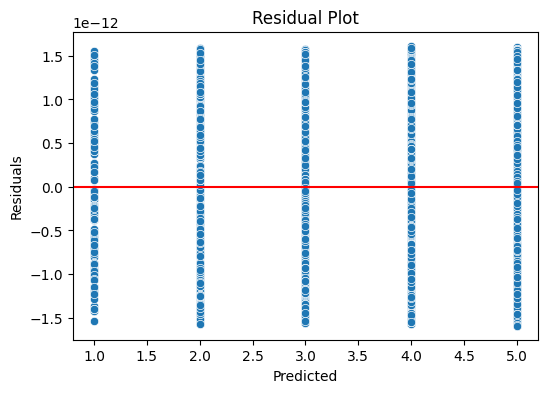

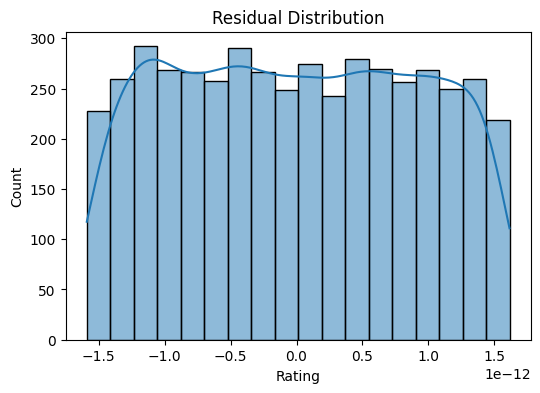

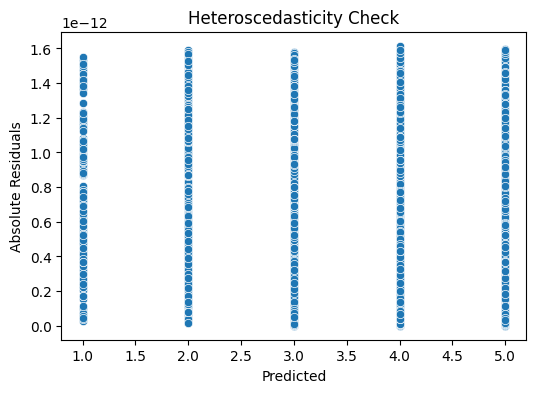

In [5]:
# =========================================
# TASK 2: MODEL EVALUATION + DIAGNOSTICS
# =========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# LOAD DATA (FIXED PATH)
# -----------------------------
df = pd.read_csv("../data/feature_engineered.csv")

target_col = "Rating"

X = df.select_dtypes(include=np.number).drop(columns=[target_col], errors="ignore")
y = df[target_col]

# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# TRAIN MODEL
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# PREDICTIONS
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# METRICS
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

# -----------------------------
# CROSS VALIDATION
# -----------------------------
cv_rmse = np.sqrt(-cross_val_score(model, X, y, cv=3, scoring="neg_mean_squared_error"))
cv_r2 = cross_val_score(model, X, y, cv=3, scoring="r2")

print("CV RMSE:", cv_rmse)
print("Average CV RMSE:", np.mean(cv_rmse))
print("Average CV R2:", np.mean(cv_r2))

# -----------------------------
# RESIDUAL ANALYSIS
# -----------------------------
residuals = y_test - y_pred

# Residual plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Distribution
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# -----------------------------
# HETEROSCEDASTICITY CHECK
# -----------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=np.abs(residuals))
plt.title("Heteroscedasticity Check")
plt.xlabel("Predicted")
plt.ylabel("Absolute Residuals")
plt.show()

Task 3: Train a Lasso and Ridge Regression model and compare results by systematically tuning the regularization strength, assessing feature shrinkage effects, and visualizing coefficient distributions to understand model behavior.

Lasso Results:
    alpha      rmse        r2
0   0.01  0.234076  0.954776
1   0.10  0.354859  0.896064
2   1.00  0.537796  0.761280
3  10.00  1.101048 -0.000616

Ridge Results:
    alpha      rmse        r2
0   0.01  0.000078  1.000000
1   0.10  0.000777  1.000000
2   1.00  0.007551  0.999953
3  10.00  0.058751  0.997151

Top Lasso Features:
 PCA_1     0.283484
PCA_13    0.034067
PCA_23    0.032390
PCA_8     0.027029
Age       0.023378
PCA_4     0.021461
PCA_6     0.016962
PCA_26    0.012649
PCA_22    0.012340
PCA_9     0.012151
dtype: float64

Top Ridge Features:
 engagement_scaled          5.740027
Positive Feedback Count    0.996872
sentiment_score            0.511311
rating_sentiment_label     0.001089
PCA_1                      0.001010
PCA_2                      0.000577
Recommended IND            0.000246
Age                        0.000214
PCA_0                      0.000212
PCA_8                      0.000167
dtype: float64


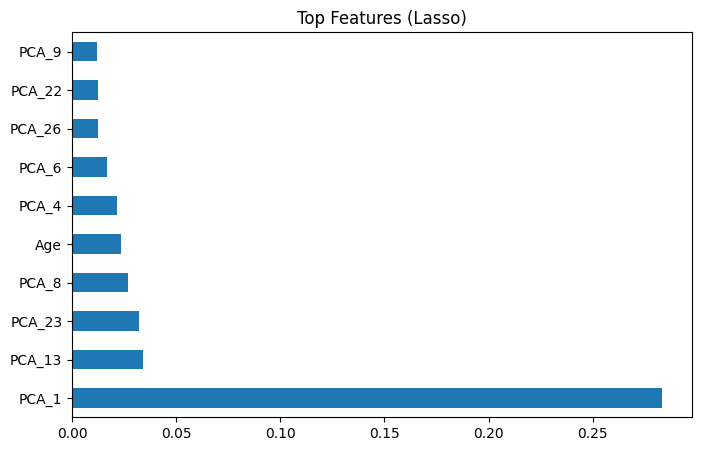

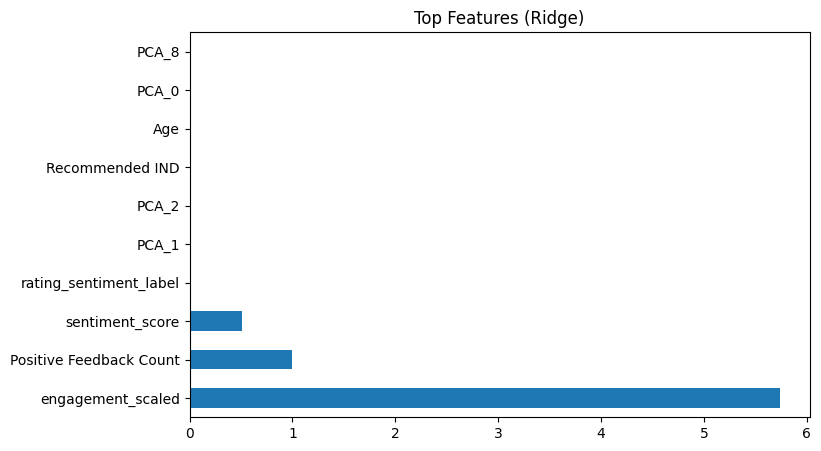

In [6]:
# =========================================
# TASK 3: LASSO + RIDGE REGRESSION
# =========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("../data/feature_engineered.csv")

target_col = "Rating"

X = df.select_dtypes(include=np.number).drop(columns=[target_col], errors="ignore")
y = df[target_col]

# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# ALPHA VALUES (TUNING)
# -----------------------------
alphas = [0.01, 0.1, 1, 10]

lasso_results = []
ridge_results = []

# -----------------------------
# TRAIN MODELS
# -----------------------------
for alpha in alphas:
    
    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_pred_lasso = lasso.predict(X_test)
    
    lasso_results.append({
        "alpha": alpha,
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        "r2": r2_score(y_test, y_pred_lasso)
    })
    
    # Ridge
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred_ridge = ridge.predict(X_test)
    
    ridge_results.append({
        "alpha": alpha,
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        "r2": r2_score(y_test, y_pred_ridge)
    })

# -----------------------------
# RESULTS
# -----------------------------
lasso_df = pd.DataFrame(lasso_results)
ridge_df = pd.DataFrame(ridge_results)

print("Lasso Results:\n", lasso_df)
print("\nRidge Results:\n", ridge_df)

# -----------------------------
# COEFFICIENT ANALYSIS
# -----------------------------
lasso = Lasso(alpha=0.1, max_iter=10000)
ridge = Ridge(alpha=0.1)

lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

lasso_coef = pd.Series(lasso.coef_, index=X.columns)
ridge_coef = pd.Series(ridge.coef_, index=X.columns)

# Top features
print("\nTop Lasso Features:\n", lasso_coef.abs().sort_values(ascending=False).head(10))
print("\nTop Ridge Features:\n", ridge_coef.abs().sort_values(ascending=False).head(10))

# -----------------------------
# VISUALIZATION
# -----------------------------
plt.figure(figsize=(8,5))
lasso_coef.abs().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top Features (Lasso)")
plt.show()

plt.figure(figsize=(8,5))
ridge_coef.abs().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top Features (Ridge)")
plt.show()

Task 4: Tune hyperparameters for better model performance using automated search techniques like GridSearchCV, RandomizedSearchCV, and Bayesian Optimization while ensuring model generalization through validation strategies.

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Load data
df = pd.read_csv("../data/feature_engineered.csv")

target_col = "Rating"

X = df.select_dtypes(include=np.number).drop(columns=[target_col], errors="ignore")
y = df[target_col]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score

# 🔥 Reduce model complexity
model = RandomForestRegressor(
    n_estimators=30,   # reduce trees
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "max_depth": [5, 10],
    "min_samples_split": [2, 5]
}

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=3,      # 🔥 very small
    cv=2,          # 🔥 reduce folds
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

# 🔥 Reduce dataset (VERY IMPORTANT)
X_train_small = X_train.sample(3000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

random_search.fit(X_train_small, y_train_small)

print("Best Params:", random_search.best_params_)

y_pred = random_search.best_estimator_.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

Best Params: {'min_samples_split': 5, 'max_depth': 10}
R2 Score: 0.9501851312285058


Task 5: Visualize the regression results with actual vs. predicted values by plotting interactive scatter plots with confidence intervals, color-coding data points based on error magnitude, and analyzing residual distributions for systematic biases.

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("../data/feature_engineered.csv")

target_col = "Rating"

X = df.select_dtypes(include=np.number).drop(columns=[target_col], errors="ignore")
y = df[target_col]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Create dataframe
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

# Error
results["Error"] = results["Actual"] - results["Predicted"]
results["Abs_Error"] = np.abs(results["Error"])

In [6]:
import numpy as np
import pandas as pd
from pathlib import Path

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# ✅ FIX: Use VS Code compatible renderer
pio.renderers.default = "browser"
# -----------------------------
# Load Data (restart-safe)
# -----------------------------
_root = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
_csv = _root / "data" / "feature_engineered.csv"

if not _csv.exists():
    raise FileNotFoundError(f"Missing {_csv}. Generate it from feature-engineering notebooks first.")

df = pd.read_csv(_csv)

# -----------------------------
# Model Training
# -----------------------------
target_col = "Rating"

if target_col not in df.columns:
    raise ValueError(f"Column '{target_col}' not found in dataset")

# Select only numeric features
X = df.select_dtypes(include=np.number).drop(columns=[target_col], errors="ignore")
y = df[target_col]

# Handle empty feature case
if X.shape[1] == 0:
    raise ValueError("No numeric features available for training.")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# -----------------------------
# Results DataFrame
# -----------------------------
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results["Error"] = results["Actual"] - results["Predicted"]
results["Abs_Error"] = results["Error"].abs()

# -----------------------------
# Plot
# -----------------------------
fig = px.scatter(
    results,
    x="Actual",
    y="Predicted",
    color="Abs_Error",
    color_continuous_scale="viridis",
    title="Actual vs Predicted (Color = Error)"
)

# Perfect prediction line
fig.add_trace(go.Scatter(
    x=results["Actual"],
    y=results["Actual"],
    mode='lines',
    name='Perfect Prediction',
    line=dict(color='red')
))

# Show plot
fig.show()